In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Mostrador vs. Local y clientes frecuentes

En este notebook se compara la venta para llevar con el consumo en el local usando los tickets
cerrados de 2025 y 2026. Para las horas se usa `Creación`, porque la hora de cierre puede cambiar
cuando se cierran varios tickets juntos al final del turno.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/Portfolio/02_Restaurant_Sales/data'

In [3]:
df = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Ventas', skiprows=3)
df_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Ventas', skiprows=3)

In [4]:
df = df[(df['Estado'] == 'Cerrada') & (df['Total'] > 0)].copy()
df['Creación'] = pd.to_datetime(df['Creación'])
df['Fecha'] = df['Creación'].dt.normalize()
df['Mes'] = df['Creación'].dt.month
df['Dia'] = df['Creación'].dt.day
df['Dia_semana'] = df['Creación'].dt.dayofweek
df['Hora'] = df['Creación'].dt.hour

df_26 = df_26[(df_26['Estado'] == 'Cerrada') & (df_26['Total'] > 0)].copy()
df_26['Creación'] = pd.to_datetime(df_26['Creación'])
df_26['Fecha'] = df_26['Creación'].dt.normalize()
df_26['Mes'] = df_26['Creación'].dt.month
df_26['Dia'] = df_26['Creación'].dt.day
df_26['Dia_semana'] = df_26['Creación'].dt.dayofweek
df_26['Hora'] = df_26['Creación'].dt.hour

# el filtro de horario de operación se aplica solo a los gráficos por hora, no a
# participación de canal, cobertura de cliente ni clientes frecuentes
ventas = pd.concat([df, df_26], ignore_index=True)
ventas = ventas[ventas['Tipo de Venta'].isin(['Local', 'Mostrador'])].copy()
ventas['Año'] = ventas['Creación'].dt.year
ventas['Semana'] = ventas['Fecha'].dt.to_period('W')
ventas['Cliente'] = ventas['Cliente'].replace(r'^\s*$', pd.NA, regex=True)

In [5]:
resumen_periodo = ventas.groupby('Año').agg(
    Tickets=('Id', 'nunique'),
    Ingresos=('Total', 'sum'),
    Inicio=('Fecha', 'min'),
    Fin=('Fecha', 'max')
)

resumen_periodo

,Tickets,Ingresos,Inicio,Fin
Año,,,,
2025,7344,1855437.47,2025-01-01,2025-12-31
2026,5234,1469431.71,2026-01-02,2026-10-06


## Participación por canal

Se comparan proporciones dentro de cada año. Esto evita comparar directamente el total de tickets
de 2026, ya que el archivo contiene un año todavía en curso.

In [6]:
canal_anual = ventas.groupby(['Año', 'Tipo de Venta']).agg(
    Tickets=('Id', 'nunique'),
    Ingresos=('Total', 'sum')
).reset_index()

canal_anual['% tickets'] = (
    canal_anual['Tickets'] /
    canal_anual.groupby('Año')['Tickets'].transform('sum') * 100
)

canal_anual['% ingresos'] = (
    canal_anual['Ingresos'] /
    canal_anual.groupby('Año')['Ingresos'].transform('sum') * 100
)

canal_anual = canal_anual.sort_values(['Año', 'Tipo de Venta'])
canal_anual.round(2)

,Año,Tipo de Venta,Tickets,Ingresos,% tickets,% ingresos
0,2025,Local,4139,1089144.57,56.36,58.70
1,2025,Mostrador,3205,766292.90,43.64,41.30
2,2026,Local,2828,896122.76,54.03,60.98
3,2026,Mostrador,2406,573308.95,45.97,39.02


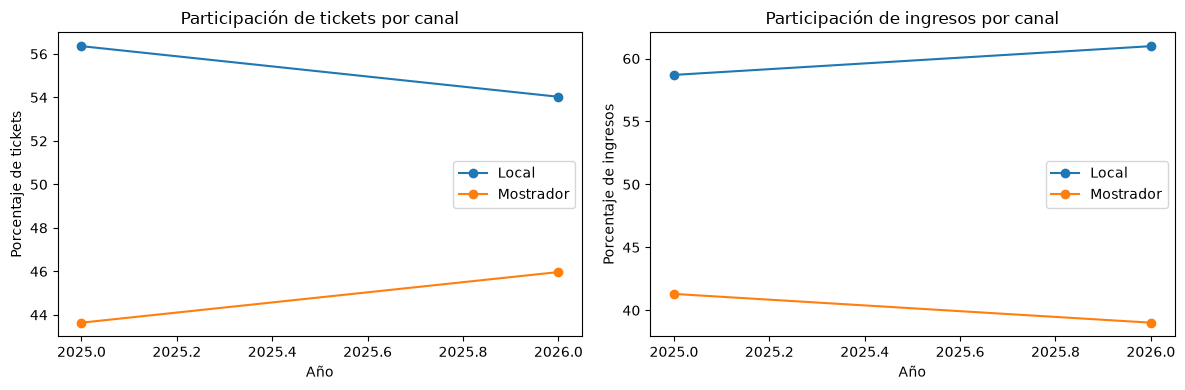

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for canal in ['Local', 'Mostrador']:
    datos = canal_anual[canal_anual['Tipo de Venta'] == canal]
    ax[0].plot(datos['Año'], datos['% tickets'], marker='o', label=canal)
    ax[1].plot(datos['Año'], datos['% ingresos'], marker='o', label=canal)

ax[0].set_title('Participación de tickets por canal')
ax[0].set_xlabel('Año')
ax[0].set_ylabel('Porcentaje de tickets')

ax[1].set_title('Participación de ingresos por canal')
ax[1].set_xlabel('Año')
ax[1].set_ylabel('Porcentaje de ingresos')

ax[0].legend()
ax[1].legend()
plt.tight_layout()

## Ticket promedio

El reporte anterior encontró cerca de $294 en Local y $229 en Mostrador durante 2026. Aquí se
actualiza el cálculo con el corte actual.

In [8]:
ticket_prom = ventas.groupby(['Año', 'Tipo de Venta']).agg(
    Tickets=('Id', 'nunique'),
    Ingresos=('Total', 'sum')
).reset_index()

ticket_prom['Ticket promedio'] = ticket_prom['Ingresos'] / ticket_prom['Tickets']
ticket_prom[['Año', 'Tipo de Venta', 'Tickets', 'Ticket promedio']].round(2)

,Año,Tipo de Venta,Tickets,Ticket promedio
0,2025,Local,4139,263.14
1,2025,Mostrador,3205,239.09
2,2026,Local,2828,316.88
3,2026,Mostrador,2406,238.28


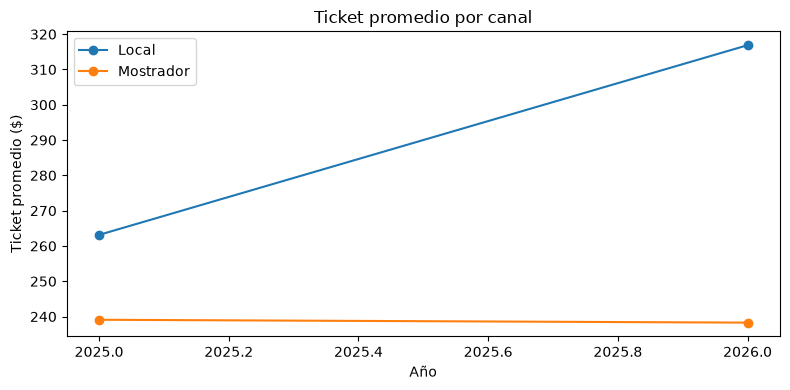

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

for canal in ['Local', 'Mostrador']:
    datos = ticket_prom[ticket_prom['Tipo de Venta'] == canal]
    ax.plot(datos['Año'], datos['Ticket promedio'], marker='o', label=canal)

ax.set_title('Ticket promedio por canal')
ax.set_xlabel('Año')
ax.set_ylabel('Ticket promedio ($)')

ax.legend()
plt.tight_layout()

## Horarios y días de la semana

Los gráficos acumulan los tickets de cada canal durante todo el periodo disponible.

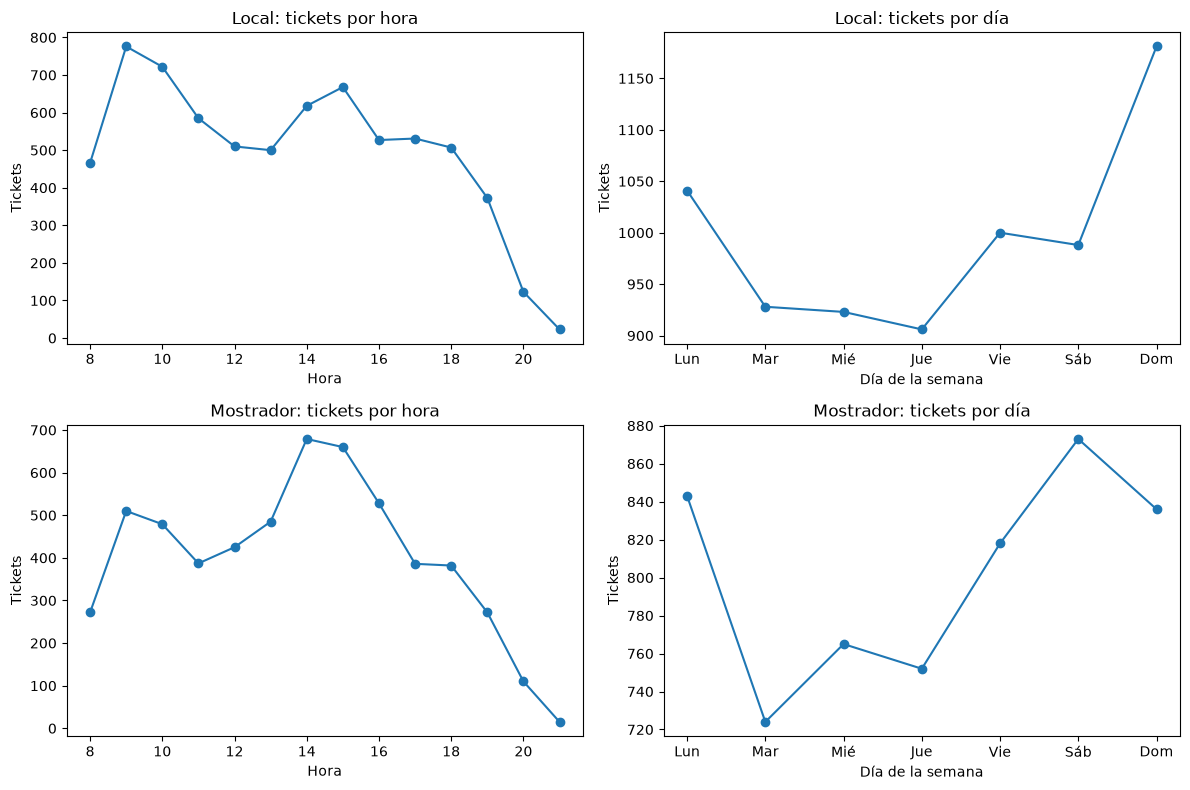

In [10]:
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

local_hora = ventas[ventas['Tipo de Venta'] == 'Local'].groupby('Hora')['Id'].nunique()
local_hora = local_hora.reindex(range(8, 22), fill_value=0)

most_hora = ventas[ventas['Tipo de Venta'] == 'Mostrador'].groupby('Hora')['Id'].nunique()
most_hora = most_hora.reindex(range(8, 22), fill_value=0)

local_dia = ventas[ventas['Tipo de Venta'] == 'Local'].groupby('Dia_semana')['Id'].nunique()
local_dia = local_dia.reindex(range(7), fill_value=0)

most_dia = ventas[ventas['Tipo de Venta'] == 'Mostrador'].groupby('Dia_semana')['Id'].nunique()
most_dia = most_dia.reindex(range(7), fill_value=0)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(local_hora.index, local_hora.values, marker='o')
ax[0, 0].set_title('Local: tickets por hora')
ax[0, 0].set_xlabel('Hora')
ax[0, 0].set_ylabel('Tickets')

ax[0, 1].plot(local_dia.index, local_dia.values, marker='o')
ax[0, 1].set_title('Local: tickets por día')
ax[0, 1].set_xlabel('Día de la semana')
ax[0, 1].set_ylabel('Tickets')
ax[0, 1].set_xticks(range(7))
ax[0, 1].set_xticklabels(dias)

ax[1, 0].plot(most_hora.index, most_hora.values, marker='o')
ax[1, 0].set_title('Mostrador: tickets por hora')
ax[1, 0].set_xlabel('Hora')
ax[1, 0].set_ylabel('Tickets')

ax[1, 1].plot(most_dia.index, most_dia.values, marker='o')
ax[1, 1].set_title('Mostrador: tickets por día')
ax[1, 1].set_xlabel('Día de la semana')
ax[1, 1].set_ylabel('Tickets')
ax[1, 1].set_xticks(range(7))
ax[1, 1].set_xticklabels(dias)

plt.tight_layout()

## Cobertura de clientes registrados

La columna `Cliente` no está llena en todos los tickets, sobre todo en Mostrador. Por eso los
resultados de clientes frecuentes representan solamente a la parte registrada y no a todos los
clientes reales del restaurante.

In [11]:
tickets_totales = ventas['Id'].nunique()
tickets_cliente = ventas.loc[ventas['Cliente'].notna(), 'Id'].nunique()
cobertura = tickets_cliente / tickets_totales

registro_canal = ventas.assign(Registrado=ventas['Cliente'].notna()).groupby('Tipo de Venta').agg(
    Tickets=('Id', 'nunique'),
    Con_cliente=('Registrado', 'sum')
)

registro_canal['% registrado'] = (
    registro_canal['Con_cliente'] / registro_canal['Tickets'] * 100
)

print(f'El {cobertura:.1%} de los tickets válidos tiene un cliente registrado.')
registro_canal.round(2)

El 10.1% de los tickets válidos tiene un cliente registrado.


,Tickets,Con_cliente,% registrado
Tipo de Venta,,,
Local,6967,0,0.00
Mostrador,5611,1271,22.65


## Clientes frecuentes

Se considera frecuente a un cliente que aparece en 4 o más semanas distintas durante el periodo.
El canal predominante es el que tiene más tickets para esa persona. Si hay empate, se deja como
empate y no se asigna a Local ni a Mostrador.

In [12]:
con_cliente = ventas[ventas['Cliente'].notna()].copy()

frecuencia = con_cliente.groupby('Cliente').agg(
    Ventas=('Id', 'nunique'),
    Semanas=('Semana', 'nunique')
)

frecuentes = frecuencia[frecuencia['Semanas'] >= 4].copy()

rec = con_cliente[con_cliente['Cliente'].isin(frecuentes.index)].copy()

canal_frec = rec.groupby(['Cliente', 'Tipo de Venta'])['Id'].nunique().unstack(fill_value=0)
canal_frec = canal_frec.reindex(columns=['Local', 'Mostrador'], fill_value=0)

canal_frec['Grupo'] = np.where(
    canal_frec['Local'] > canal_frec['Mostrador'],
    'Local',
    np.where(canal_frec['Mostrador'] > canal_frec['Local'], 'Mostrador', 'Empate')
)

canal_frec['Ventas'] = rec.groupby('Cliente')['Id'].nunique()

semanas_periodo = ventas['Semana'].nunique()
canal_frec['Compras por semana'] = canal_frec['Ventas'] / semanas_periodo

rec['Grupo'] = rec['Cliente'].map(canal_frec['Grupo'])

resumen_frec = canal_frec.groupby('Grupo').agg(
    Clientes=('Ventas', 'size'),
    Compras_promedio=('Ventas', 'mean'),
    Compras_por_semana=('Compras por semana', 'mean')
)

resumen_frec = resumen_frec.reindex(['Local', 'Mostrador', 'Empate']).fillna(0)
resumen_frec['% frecuentes'] = resumen_frec['Clientes'] / len(canal_frec) * 100

print(f'Clientes frecuentes identificados: {len(canal_frec)}')
print(f'Semanas incluidas en el corte: {semanas_periodo}')
resumen_frec.round(2)

Clientes frecuentes identificados: 43
Semanas incluidas en el corte: 93


,Clientes,Compras_promedio,Compras_por_semana,% frecuentes
Grupo,,,,
Local,0.0,0.00,0.00,0.0
Mostrador,43.0,12.91,0.14,100.0
Empate,0.0,0.00,0.00,0.0


## Lectura y acciones

In [13]:
mix = canal_anual.pivot(index='Año', columns='Tipo de Venta', values='% tickets')
ticket_tab = ticket_prom.pivot(index='Año', columns='Tipo de Venta', values='Ticket promedio')

cambio_local = mix.loc[2026, 'Local'] - mix.loc[2025, 'Local']
var_ticket_local = (ticket_tab.loc[2026, 'Local'] / ticket_tab.loc[2025, 'Local'] - 1) * 100
var_ticket_most = (ticket_tab.loc[2026, 'Mostrador'] / ticket_tab.loc[2025, 'Mostrador'] - 1) * 100

canal_mas_frec = resumen_frec.loc[['Local', 'Mostrador'], 'Compras_por_semana'].idxmax()

local_frec_dia = rec[rec['Grupo'] == 'Local'].groupby('Dia_semana')['Id'].nunique()
local_frec_dia = local_frec_dia.reindex(range(7), fill_value=0)
dia_bajo = dias[local_frec_dia.idxmin()]

canal_mayor_26 = mix.loc[2026].idxmax()
fecha_corte = ventas[ventas['Año'] == 2026]['Fecha'].max().strftime('%d-%m-%Y')

print('Lectura del corte')
print(f'2026 llega hasta {fecha_corte}; por eso se comparan participaciones y tickets promedio, no totales anuales.')
print(f'Local cambió {cambio_local:+.1f} puntos porcentuales en participación de tickets frente a 2025.')
print(f'El ticket promedio de Local cambió {var_ticket_local:+.1f}% y el de Mostrador {var_ticket_most:+.1f}%.')
print('Esto coincide con la mudanza, el local más grande, el ajuste de precio de enero y el retiro del mercado en noviembre de 2025, aunque este análisis no mide cuánto aportó cada factor.')

print('\nAcciones propuestas')
if canal_mas_frec == 'Mostrador':
    print('1. Probar una tarjeta de sellos para Mostrador: este es el grupo frecuente con más compras semanales en promedio.')
else:
    print('1. Probar un beneficio de recurrencia para consumo Local: este es el grupo frecuente con más compras semanales en promedio.')

print(f'2. Activar una promoción de visita en Local los {dia_bajo}, que es el día con menos tickets de frecuentes predominantemente Local.')

if canal_mayor_26 == 'Mostrador':
    print('3. Probar un combo rápido para llevar en Mostrador y medir si ayuda a sostener el canal con mayor participación en 2026.')
else:
    print('3. Probar un combo exclusivo para mesa en Local y medir si ayuda a sostener el canal con mayor participación en 2026.')

print(f'\nPara medir mejor estas promociones, conviene pedir el registro voluntario del cliente en caja: hoy solo se registra el {cobertura:.1%} de los tickets.')

Lectura del corte
2026 llega hasta 06-10-2026; por eso se comparan participaciones y tickets promedio, no totales anuales.
Local cambió -2.3 puntos porcentuales en participación de tickets frente a 2025.
El ticket promedio de Local cambió +20.4% y el de Mostrador -0.3%.
Esto coincide con la mudanza, el local más grande, el ajuste de precio de enero y el retiro del mercado en noviembre de 2025, aunque este análisis no mide cuánto aportó cada factor.

Acciones propuestas
1. Probar una tarjeta de sellos para Mostrador: este es el grupo frecuente con más compras semanales en promedio.
2. Activar una promoción de visita en Local los Lun, que es el día con menos tickets de frecuentes predominantemente Local.
3. Probar un combo exclusivo para mesa en Local y medir si ayuda a sostener el canal con mayor participación en 2026.

Para medir mejor estas promociones, conviene pedir el registro voluntario del cliente en caja: hoy solo se registra el 10.1% de los tickets.
